In [1]:
import sys
if '/home/jovyan/src' not in sys.path:
    sys.path.append('/home/jovyan/src')

from spark_utils import crear_spark_session
from gold.predictivo import construir_features_clustering

In [2]:
spark_build = crear_spark_session()
construir_features_clustering(spark_build)
spark_build.stop()

2026-07-17 08:50:52,115 [INFO] SparkSession creada: 3.5.0
2026-07-17 08:51:49,158 [INFO] Gold escrito (overwrite): predictivo/features_clustering (264 filas)
2026-07-17 08:51:59,256 [INFO] features_clustering: 264 zonas


In [2]:
spark = crear_spark_session()

df_cluster_spark = spark.read.parquet("/home/jovyan/data/gold/predictivo/features_clustering/")
df_cluster_spark.show(5)
print(f"Total zonas: {df_cluster_spark.count()}")

df_cluster_pd = df_cluster_spark.toPandas()
spark.stop()

2026-07-17 08:54:32,145 [INFO] SparkSession creada: 3.5.0


+-----------+------------+-------------+------------------+-----------------+--------------------+-------------+
|location_id|total_viajes|fare_promedio|distancia_promedio|duracion_promedio|hora_promedio_salida|pct_hora_pico|
+-----------+------------+-------------+------------------+-----------------+--------------------+-------------+
|         35|     4376247|        18.42|              3.59|             17.6|               13.03|        0.228|
|        189|     2628221|        24.34|              4.31|            20.67|               14.13|        0.192|
|         23|     1222895|        22.59|              5.94|             17.7|               12.91|        0.226|
|        121|     1607096|        22.04|              5.22|            18.83|               12.96|        0.225|
|         41|     5148955|        21.41|              4.24|            17.83|               13.51|         0.22|
+-----------+------------+-------------+------------------+-----------------+-------------------

2026-07-17 08:54:38,227 [INFO] NumExpr defaulting to 4 threads.


Total zonas: 264


In [5]:
spark = crear_spark_session()
from config import GOLD_PATH
spark.read.parquet(str(GOLD_PATH / "predictivo" / "features_clustering")).count()


2026-07-17 08:55:44,623 [INFO] SparkSession creada: 3.5.0


264

In [6]:
spark.stop()

In [7]:
spark = crear_spark_session()

df_cluster_spark = spark.read.parquet(str(GOLD_PATH / "predictivo" / "features_clustering"))
df_cluster_pd = df_cluster_spark.toPandas()

df_cluster_pd.describe()

2026-07-17 14:13:47,182 [INFO] SparkSession creada: 3.5.0


,location_id,total_viajes,fare_promedio,distancia_promedio,duracion_promedio,hora_promedio_salida,pct_hora_pico
count,264.000000,2.640000e+02,263.000000,263.000000,264.000000,264.000000,264.000000
mean,133.113636,3.214781e+06,23.577072,4.913080,19.146705,13.307008,0.215553
std,76.766313,3.154976e+06,6.553868,1.415525,4.036634,0.891140,0.029720
min,1.000000,2.000000e+00,15.430000,2.890000,12.000000,10.850000,0.000000
25%,66.750000,1.012380e+06,19.925000,4.140000,17.165000,12.760000,0.202000
50%,133.500000,2.233594e+06,21.910000,4.550000,18.320000,13.110000,0.223000
75%,199.250000,4.565526e+06,25.015000,5.180000,19.882500,13.782500,0.235000
max,265.000000,1.864398e+07,79.740000,17.140000,51.840000,21.000000,0.267000


In [8]:
df_cluster_pd.isnull().sum()

location_id             0
total_viajes            0
fare_promedio           1
distancia_promedio      1
duracion_promedio       0
hora_promedio_salida    0
pct_hora_pico           0
dtype: int64

In [9]:
df_cluster_pd.sort_values("location_id", ascending=False).head(5)

,location_id,total_viajes,fare_promedio,distancia_promedio,duracion_promedio,hora_promedio_salida,pct_hora_pico
174,265,162215,43.42,7.40,36.17,12.45,0.193
183,264,509224,21.13,3.96,17.29,14.21,0.207
210,263,6132510,22.64,4.36,17.30,13.41,0.221
35,262,4251889,22.53,4.25,17.11,13.00,0.267
55,261,3336133,35.17,6.29,24.51,14.46,0.202


In [10]:
df_cluster_pd[df_cluster_pd["location_id"].isin([264, 265])]

,location_id,total_viajes,fare_promedio,distancia_promedio,duracion_promedio,hora_promedio_salida,pct_hora_pico
174,265,162215,43.42,7.40,36.17,12.45,0.193
183,264,509224,21.13,3.96,17.29,14.21,0.207


In [11]:
# Excluir códigos especiales no geográficos (264=N/A, 265=Outside NYC)
df_cluster_pd = df_cluster_pd[~df_cluster_pd["location_id"].isin([264, 265])]

# Descartar las 1-2 filas con nulos (zonas con datos incompletos, insuficientes para clustering)
df_cluster_pd = df_cluster_pd.dropna()

print(f"Zonas finales para clustering: {len(df_cluster_pd)}")

Zonas finales para clustering: 261


In [14]:
from sklearn.preprocessing import StandardScaler

features_cols = ["total_viajes", "fare_promedio", "distancia_promedio",
                  "duracion_promedio", "hora_promedio_salida", "pct_hora_pico"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster_pd[features_cols])

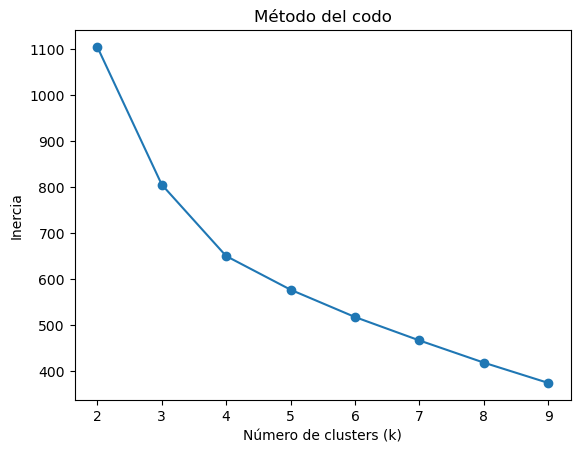

In [15]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inercias = []
rango_k = range(2, 10)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

plt.plot(rango_k, inercias, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

In [16]:
# Instanciar el modelo definitivo con el k óptimo
k_optimo = 4
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

df_cluster_pd['cluster'] = kmeans_final.fit_predict(X_scaled)

perfil = df_cluster_pd.groupby('cluster')[features_cols].mean().round(2)

perfil['n_zonas'] = df_cluster_pd['cluster'].value_counts()

display(perfil)

,total_viajes,fare_promedio,distancia_promedio,duracion_promedio,hora_promedio_salida,pct_hora_pico,n_zonas
cluster,,,,,,,
0,6261525.57,24.44,4.26,19.34,13.77,0.19,72
1,1113110.23,32.07,6.97,23.58,14.28,0.20,26
2,2072788.68,20.91,4.73,17.64,12.87,0.23,160
3,12204629.67,65.85,11.90,40.30,14.50,0.17,3


In [17]:
import numpy as np

condiciones = [
    df_cluster_pd['cluster'] == 0,
    df_cluster_pd['cluster'] == 1,
    df_cluster_pd['cluster'] == 2,
    df_cluster_pd['cluster'] == 3
]
valores = [
    'Hubs Alta Demanda',   # Cluster 0
    'Viajes Periféricos',  # Cluster 1
    'Tránsito Diario',     # Cluster 2
    'Aeropuertos'          # Cluster 3
]
df_cluster_pd['perfil_zona'] = np.select(condiciones, valores, default='Otro')

df_cluster_spark_final = spark.createDataFrame(df_cluster_pd)

dim_cluster_zonas = df_cluster_spark_final.select("location_id", "cluster", "perfil_zona")

destino_gold = str(GOLD_PATH / "predictivo" / "dim_cluster_zonas")
dim_cluster_zonas.write.mode("overwrite").parquet(destino_gold)

print("¡Dimensión de clusters guardada exitosamente en Gold!")

¡Dimensión de clusters guardada exitosamente en Gold!
